Source: [NCHS / CDC](https://www.cdc.gov/nchs/fastats/life-expectancy.htm)<br>
[List of U.S. states and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_life_expectancy) <i>([alternative design](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_U.S._states_and_territories_by_life_expectancy_(alternative)))</i> / [Продолжительность жизни в штатах США](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_штатах_США)<br>
[MapChart](https://www.mapchart.net/usa.html)<br>
[chart from the National Vital Statisctics Reports at wiki](https://en.wikipedia.org/wiki/File:Percentage_Surviving_to_Certain_Ages_in_the_U.S..png)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import re
from collections import namedtuple

# import sys
# sys.path.append("..")
# import mal_moduls_private.mal_total as mal

In [3]:
pd.options.display.min_rows=4

In [4]:
LANG = 'en'
DESTINATION_OUTPUT = 'show'  # to where table code should be placed: 'file', 'show'

In [5]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'color', 'style', 'width', 'alpha'])

In [6]:
def read_single_csv(file_name):
    return pd.read_csv(f"data 2019 number of surviving/{file_name}", sep='\t',
                usecols=['Age', 'Number_surviving_to_age'], index_col='Age', decimal=',')

ls_files = ['All population, males.csv',
            'All population, total.csv',
            'All population, females.csv',
            'Hispanic population, males.csv',
            'Hispanic population, total.csv',
            'Hispanic population, females.csv',
            'American Indian or Alaska Native population, males.csv',
            'American Indian or Alaska Native population, total.csv',
            'American Indian or Alaska Native population, females.csv',
            'Asian population, males.csv',
            'Asian population, total.csv',
            'Asian population, females.csv',
            'Black population, males.csv',
            'Black population, total.csv',
            'Black population, females.csv',
            'White population, males.csv',
            'White population, total.csv',
            'White population, females.csv']

df = pd.concat([read_single_csv(file_name) for file_name in ls_files], axis='columns')
df.index.name = ''
df.rename(index=lambda st: st.split('–')[0], inplace=True)
df.columns = ['all_m', 'all_t', 'all_f',
              'hispanic_m', 'hispanic_t', 'hispanic_f',
              'native_m', 'native_t', 'native_f',
              'asian_m', 'asian_t', 'asian_f',
              'black_m', 'black_t', 'black_f',
              'white_m', 'white_t', 'white_f']

df

,all_m,all_t,all_f,hispanic_m,hispanic_t,hispanic_f,native_m,native_t,native_f,asian_m,asian_t,asian_f,black_m,black_t,black_f,white_m,white_t,white_f
,,,,,,,,,,,,,,,,,,
0,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000
1,99.392,99.443,99.496,99.452,99.497,99.543,99.135,99.213,99.294,99.637,99.663,99.690,98.859,98.939,99.021,99.506,99.552,99.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,1.663,3.024,4.244,3.483,6.425,8.212,2.155,3.667,5.095,5.919,8.822,10.635,1.659,3.240,4.588,1.488,2.773,3.931
100,1.092,2.090,2.976,2.436,4.768,6.113,1.623,2.852,3.991,4.216,6.512,7.862,1.196,2.414,3.433,0.959,1.893,2.727


In [7]:
dd_display = {
    'all_f'       : DisplayedGroup(en_name='Males on average',      ru_name='мужчины в целом',         color='lightgrey',  style=':',  width=6, alpha=1),
    'all_t'       : DisplayedGroup(en_name='Population on average', ru_name='население в целом',       color='lightgrey',  style='-',  width=12, alpha=1),
    'all_m'       : DisplayedGroup(en_name='Females on average',    ru_name='женщины в целом',         color='lightgrey',  style='--', width=6, alpha=1),
    'asian_f'     : DisplayedGroup(en_name='Asian female',     ru_name='Азиаты -женщины',           color='darkorange', style=':',  width=2, alpha=1),
    'asian_t'     : DisplayedGroup(en_name='Asian on average',    ru_name='Азиаты -в целом',           color='darkorange', style='-',  width=4, alpha=1),
    'asian_m'     : DisplayedGroup(en_name='Asian male',       ru_name='Азиаты -мужчины',           color='darkorange', style='--', width=2, alpha=1),
    'hispanic_f'  : DisplayedGroup(en_name='Hispanic female',  ru_name='Латиноамериканцы -женщины', color='red',        style=':',  width=2, alpha=1),
    'hispanic_t'  : DisplayedGroup(en_name='Hispanic on average', ru_name='Латиноамериканцы -в целом', color='red',        style='-',  width=4, alpha=1),
    'hispanic_m'  : DisplayedGroup(en_name='Hispanic male',    ru_name='Латиноамериканцы -мужчины', color='red',        style='--', width=2, alpha=1),
    'white_f'     : DisplayedGroup(en_name='White female',     ru_name='Белые -женщины',            color='blue',       style=':',  width=2, alpha=1),
    'white_t'     : DisplayedGroup(en_name='White on average',    ru_name='Белые -в целом',            color='blue',       style='-',  width=4, alpha=1),
    'white_m'     : DisplayedGroup(en_name='White male',       ru_name='Белые -мужчины',            color='blue',       style='--', width=2, alpha=1),
    'black_f'     : DisplayedGroup(en_name='Black female',     ru_name='Афроамериканцы -женщины',   color='#444444',    style=':',  width=2, alpha=1),
    'black_t'     : DisplayedGroup(en_name='Black on average',    ru_name='Афроамериканцы -в целом',   color='#444444',    style='-',  width=4, alpha=1),
    'black_m'     : DisplayedGroup(en_name='Black male',       ru_name='Афроамериканцы -мужчины',   color='#444444',    style='--', width=2, alpha=1),
    'native_f'    : DisplayedGroup(en_name='Natives female',   ru_name='Коренные народы -женщины',  color='lime',       style=':',  width=2, alpha=1),
    'native_t'    : DisplayedGroup(en_name='Natives on average',  ru_name='Коренные народы -в целом',  color='lime',       style='-',  width=4, alpha=1),
    'native_m'    : DisplayedGroup(en_name='Natives male',     ru_name='Коренные народы -мужчины',  color='lime',       style='--', width=2, alpha=1),
}

# 'all_fΔm'     : DisplayedGroup(en_name='Population sex gap', ru_name='Межполовая разница в целом', color='lightgrey', style='-', width=6, alpha=1),
# 'asian_fΔm'   : DisplayedGroup(en_name='Asian sex gap',    ru_name='Межполовая разница для азиатов', color='darkorange', style='-', width=2.5, alpha=1),
# 'hispanic_fΔm': DisplayedGroup(en_name='Hispanic sex gap', ru_name='Межполовая разница для латиноамериканцев', color='red', style='-', width=2.5, alpha=1),
# 'white_fΔm'   : DisplayedGroup(en_name='White sex gap',    ru_name='Межполовая разница для белых', color='blue',    style='-', width=2.5, alpha=1),
# 'black_fΔm'   : DisplayedGroup(en_name='Black sex gap',    ru_name='Межполовая разница для афроамериканцев', color='#444444', style='-', width=2.5, alpha=1),
# 'native_fΔm'   : DisplayedGroup(en_name='Natives sex gap', ru_name='Межполовая разница для коренных народов', color='lime', style='-', width=2.5, alpha=1),

<br>

In [9]:
def create_chart(
        df, lang=LANG, dd_display=dd_display, ncol=2,
        title_en='Title of the chart', title_ru='Заголовок графика',
        destination=DESTINATION_OUTPUT, file_name=''):

    plt.rcParams['figure.figsize'] = (16, 12.5) if lang=='ru' else (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()  # show ticks only at the left side
    ax.yaxis.set_label_position("right")  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=3)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=5, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=3)  # Minor ticks are shorter
    plt.xticks(fontsize=12)  # font size for tick labels
    plt.yticks(fontsize=12)
    
    x_min = y_min = 0
    x_max = y_max = 100
    plt.xlim(0, 100)
    plt.ylim(0, 101)

    # for version with ratio
    # labels_y = range(y_min, y_max+1, 10)
    # y_labels_names = ((f"{v/100:.1f}" if v % 100 != 0  else v//100) for v in labels_y)
    # plt.yticks(labels_y, labels=y_labels_names)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.3)

    plt.title(title_ru if lang=='ru' else title_en, fontsize=15)
    plt.xlabel('Возраст, годы' if lang=='ru' else 'Age, years', fontsize=13, color='darkgray', labelpad=-0.5)
    plt.ylabel('Процент выживших' if lang=='ru' else 'Percent surviving', fontsize=13, color='darkgray', labelpad=-3.5)
    # plt.ylabel('Доля выживших' if lang=='ru' else 'Survival Rate', fontsize=13, color='darkgray')  # , labelpad=-2

    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='lower left', fontsize=13, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print('Data has written to file')
    else:
        plt.show()


# create_chart(df.T.loc[['asian_f', 'hispanic_f', 'white_f', 'black_f', 'native_f', 'asian_m', 'hispanic_m', 'white_m', 'black_m', 'native_m']],
#              dd_display=dd_display, ncol=2, lang=LANG,
#              file_name='Probability to live till a certain age -all')

<br>

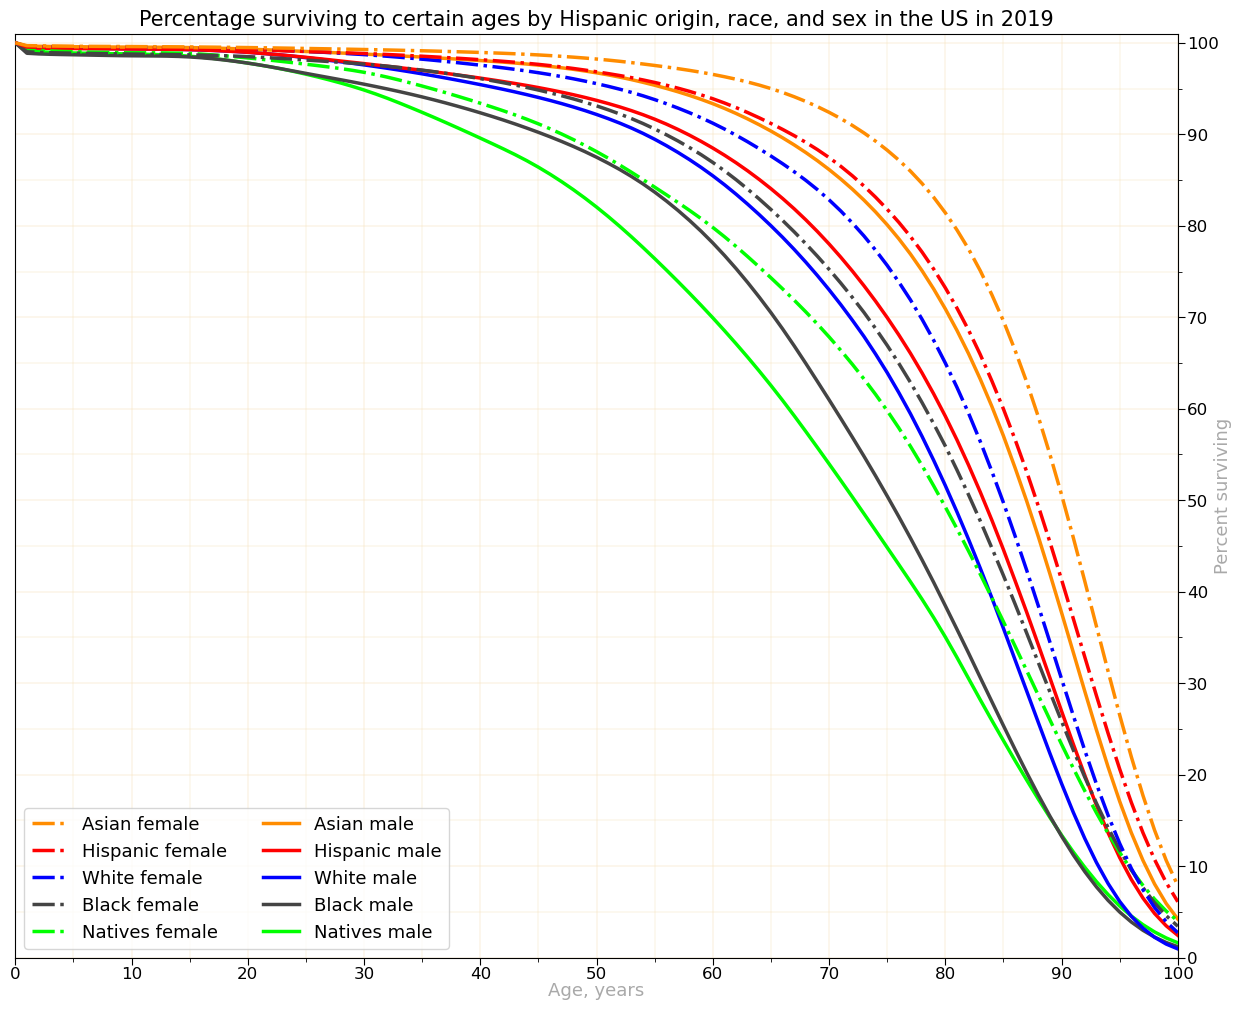

In [11]:
dd_display = {
    'asian_f'     : DisplayedGroup(en_name='Asian female',     ru_name='Азиаты -женщины',           color='darkorange', style='-.',  width=2.5, alpha=1),
    'asian_m'     : DisplayedGroup(en_name='Asian male',       ru_name='Азиаты -мужчины',           color='darkorange', style='-', width=2.5, alpha=1),
    'hispanic_f'  : DisplayedGroup(en_name='Hispanic female',  ru_name='Латиноамериканцы -женщины', color='red',        style='-.',  width=2.5, alpha=1),
    'hispanic_m'  : DisplayedGroup(en_name='Hispanic male',    ru_name='Латиноамериканцы -мужчины', color='red',        style='-', width=2.5, alpha=1),
    'white_f'     : DisplayedGroup(en_name='White female',     ru_name='Белые -женщины',            color='blue',       style='-.',  width=2.5, alpha=1),
    'white_m'     : DisplayedGroup(en_name='White male',       ru_name='Белые -мужчины',            color='blue',       style='-', width=2.5, alpha=1),
    'black_f'     : DisplayedGroup(en_name='Black female',     ru_name='Афроамериканцы -женщины',   color='#444444',    style='-.',  width=2.5, alpha=1),
    'black_m'     : DisplayedGroup(en_name='Black male',       ru_name='Афроамериканцы -мужчины',   color='#444444',    style='-', width=2.5, alpha=1),
    'native_f'    : DisplayedGroup(en_name='Natives female',   ru_name='Коренные жители -женщины',  color='lime',       style='-.',  width=2.5, alpha=1),
    'native_m'    : DisplayedGroup(en_name='Natives male',     ru_name='Коренные жители -мужчины',  color='lime',       style='-', width=2.5, alpha=1),
}

create_chart(df.T.loc[['asian_f', 'hispanic_f', 'white_f', 'black_f', 'native_f', 'asian_m', 'hispanic_m', 'white_m', 'black_m', 'native_m']],
             dd_display=dd_display, ncol=2, lang=LANG,
             title_en='Percentage surviving to certain ages by Hispanic origin, race, and sex in the US in 2019',
             title_ru='Процент выживших к определённому возрасту в зависимости от происхождения, расы и пола в США в 2019',
             file_name='Percentage Surviving to Certain Ages in the US')

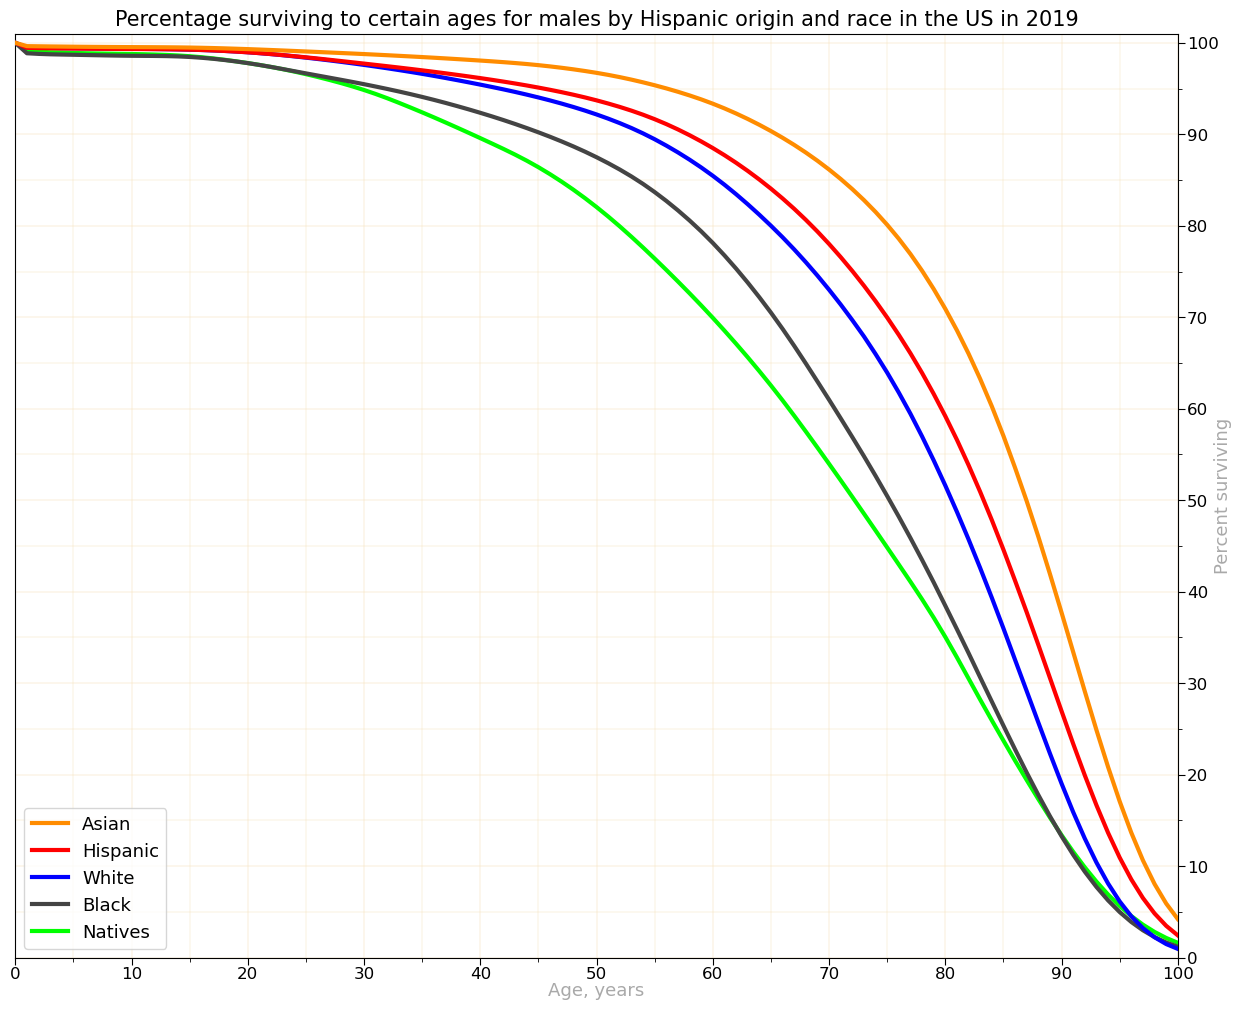

In [12]:
dd_display = {
    'asian_m'     : DisplayedGroup(en_name='Asian',       ru_name='Азиаты',           color='darkorange', style='-', width=3, alpha=1),
    'hispanic_m'  : DisplayedGroup(en_name='Hispanic',    ru_name='Латиноамериканцы', color='red',        style='-', width=3, alpha=1),
    'white_m'     : DisplayedGroup(en_name='White',       ru_name='Белые',            color='blue',       style='-', width=3, alpha=1),
    'black_m'     : DisplayedGroup(en_name='Black',       ru_name='Афроамериканцы',   color='#444444',    style='-', width=3, alpha=1),
    'native_m'    : DisplayedGroup(en_name='Natives',     ru_name='Коренные жители',  color='lime',       style='-', width=3, alpha=1),
}

create_chart(df.T.loc[['asian_m', 'hispanic_m', 'white_m', 'black_m', 'native_m']],
             dd_display=dd_display, ncol=1, lang=LANG,
             title_en='Percentage surviving to certain ages for males by Hispanic origin and race in the US in 2019',
             title_ru='Процент выживших к определённому возрасту мужчин в зависимости от происхождения и расы в США в 2019',
             file_name='Percentage Surviving to Certain Ages in the US -males')

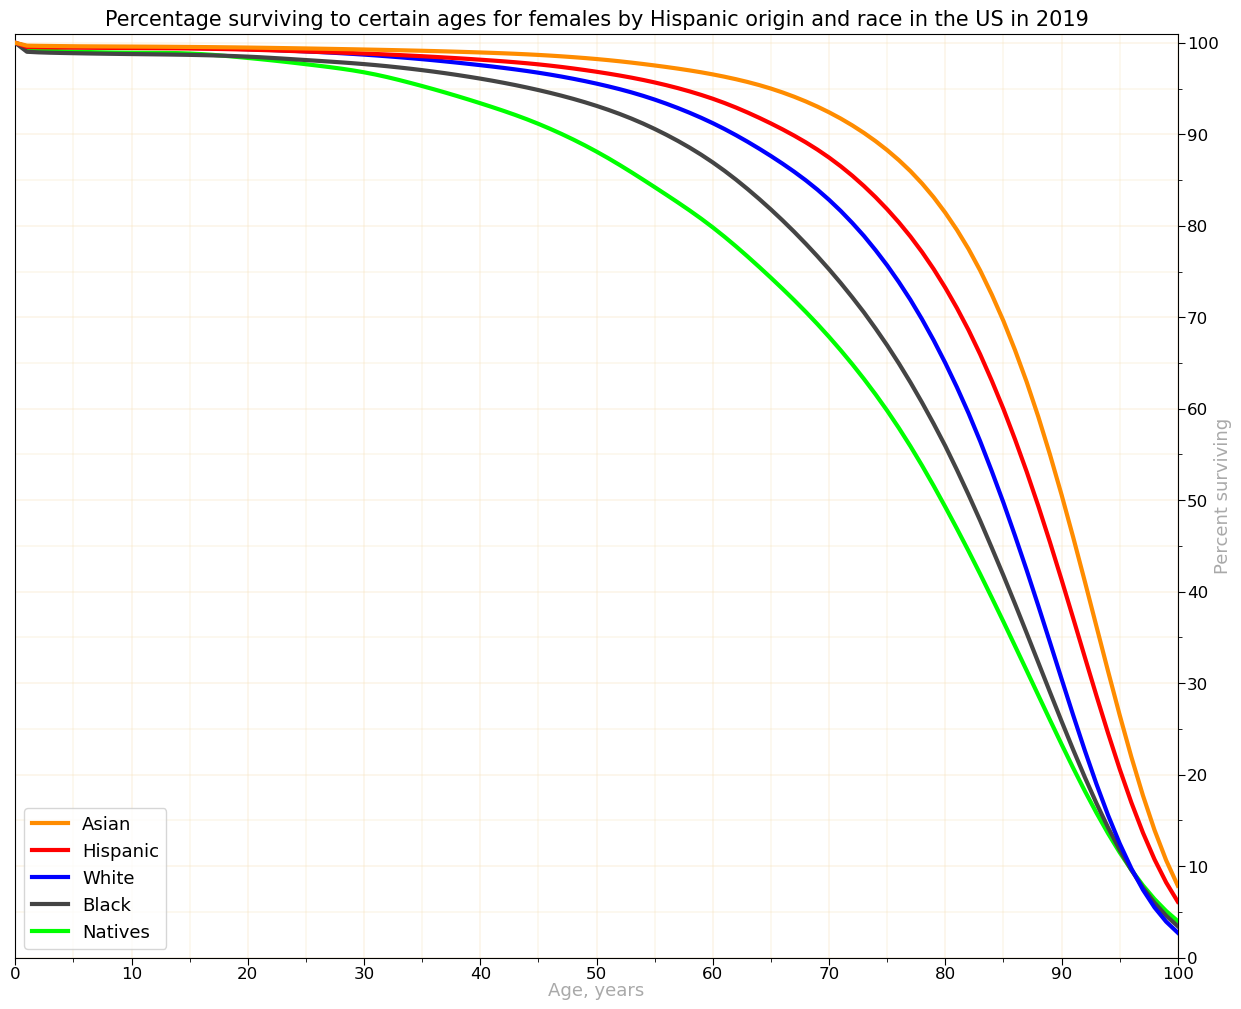

In [13]:
dd_display = {
    'asian_f'     : DisplayedGroup(en_name='Asian',     ru_name='Азиатки',           color='darkorange', style='-',  width=3, alpha=1),
    'hispanic_f'  : DisplayedGroup(en_name='Hispanic',  ru_name='Латиноамериканки', color='red',        style='-',  width=3, alpha=1),
    'white_f'     : DisplayedGroup(en_name='White',     ru_name='Белые',            color='blue',       style='-',  width=3, alpha=1),
    'black_f'     : DisplayedGroup(en_name='Black',     ru_name='Афроамериканки',   color='#444444',    style='-',  width=3, alpha=1),
    'native_f'    : DisplayedGroup(en_name='Natives',   ru_name='Коренные жительницы',  color='lime',       style='-',  width=3, alpha=1)
}

create_chart(df.T.loc[['asian_f', 'hispanic_f', 'white_f', 'black_f', 'native_f']],
             dd_display=dd_display, ncol=1, lang=LANG,
             title_en='Percentage surviving to certain ages for females by Hispanic origin and race in the US in 2019',
             title_ru='Процент выживших к определённому возрасту женщин в зависимости от происхождения и расы в США в 2019',
             file_name='Percentage Surviving to Certain Ages in the US -females')

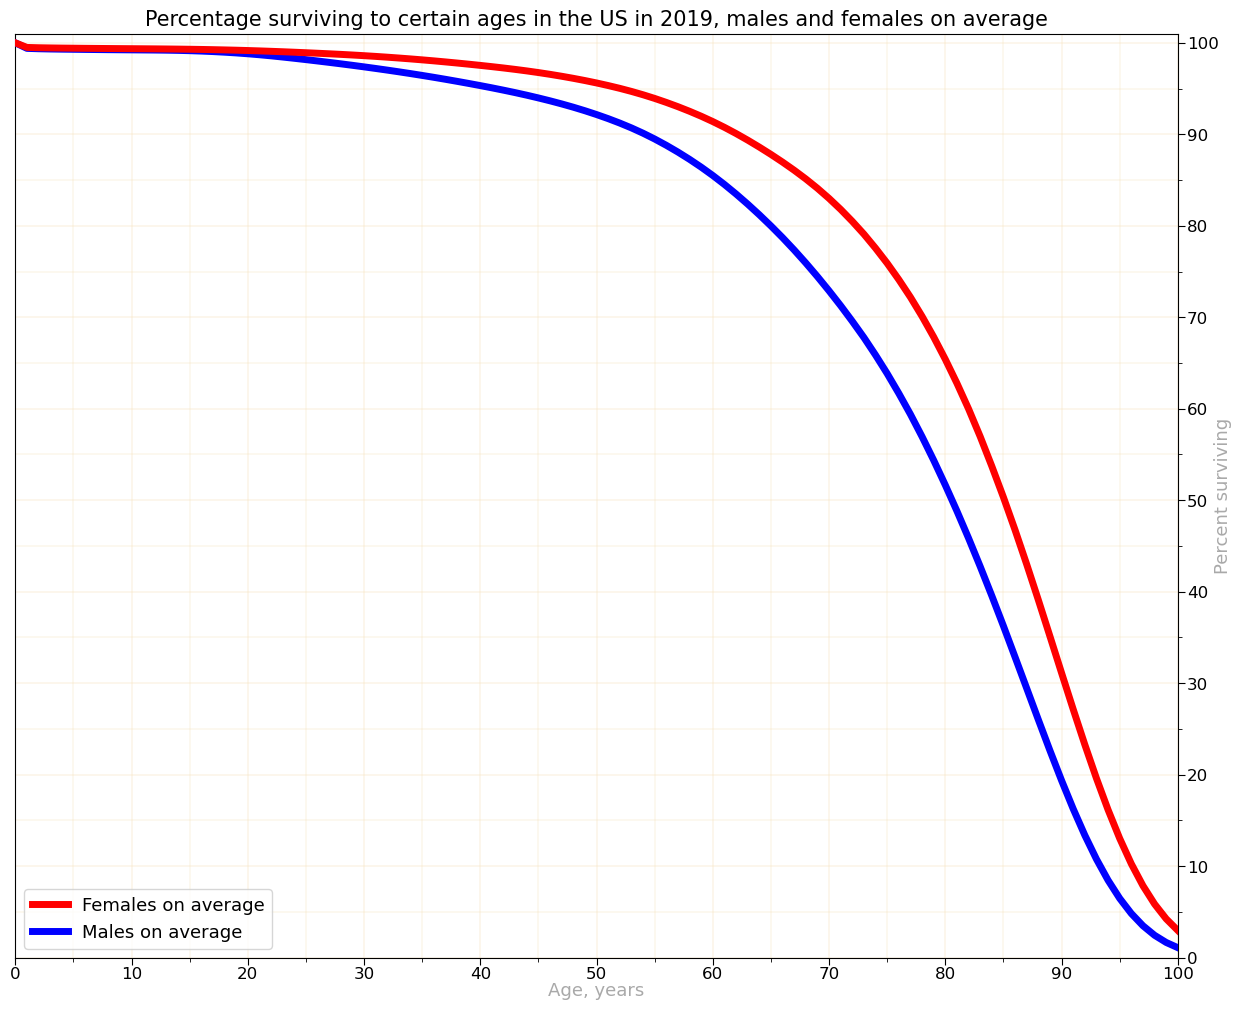

In [14]:
dd_display = {
    'all_f'       : DisplayedGroup(en_name='Females on average',      ru_name='Женщины в среднем',         color='red',  style='-',  width=5, alpha=1),
    # 'all_t'       : DisplayedGroup(en_name='Population Overall', ru_name='население в целом',       color='lightgrey',  style='-',  width=6, alpha=1),
    'all_m'       : DisplayedGroup(en_name='Males on average',    ru_name='Мужчины в среднем',         color='blue',  style='-', width=5, alpha=1),
}

create_chart(df.T.loc[['all_f', 'all_m']],
             dd_display=dd_display, ncol=1, lang=LANG,
             title_en='Percentage surviving to certain ages in the US in 2019, males and females on average',  # , overall statistics for males and females
             title_ru='Процент выживших к определённому возрасту в США в 2019, мужчины и женщины в среднем',
             file_name='Percentage Surviving to Certain Ages in the US -average')

<br>
<br>

<hr>

In [16]:
dd_replacement = {
    'all_m' : {'en': 'total population', 'ru': 'Население в целом'},
    'asian_m' : {'en': 'non-Hispanic Asian', 'ru': '{{comment|Азиаты|non-Hispanic Asian population}}'},
    'hispanic_m' : {'en': 'Hispanic', 'ru': '{{comment|Латиноамериканцы|Hispanic population}}'},
    'white_m' : {'en': 'non-Hispanic White', 'ru': '{{comment|Белые|non-Hispanic White population}}'},
    'black_m' : {'en': 'non-Hispanic Black', 'ru': '{{comment|Афроамериканцы|non-Hispanic Black population}}'},
    'native_m' : {'en': 'non-Hispanic American Indian or Alaska Native', 'ru': '{{comment|Индейцы и коренные жители Аляски|non-Hispanic American Indian or Alaska Native population}}'}
}

In [17]:
# create code for placing info in Wikipedia
def create_table_v1(df, file_header, lang='ru'):

    def if_value(x, prec=1):
        return '—' if math.isnan(x) else \
               f"{x:0.{prec}f}"  if x>=0 else \
               f"−{-x:0.{prec}f}"

    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in range(0, len(df), 2):
        ser_m = df.iloc[i]
        ser_f = df.iloc[i+1]
        name_inserted = dd_replacement[ser_m.name][lang]
        if ser_m.name == 'all_m':
            st += '\n' + '|-\n' + \
                  f'|style="text-align:left;"| \'\'\'{name_inserted}\'\'\' ' + \
                  f'||style="color:blue;"| \'\'\'{if_value(ser_m.loc['65'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['65'])}\'\'\' ' + \
                  f'||style="color:blue;border-left-width:2px;"| \'\'\'{if_value(ser_m.loc['85'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['85'])}\'\'\' ' + \
                  f'||style="color:blue;border-left-width:2px;"| \'\'\'{if_value(ser_m.loc['100'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['100'])}\'\'\''
        else:
            st += '\n' + '|-\n' + \
                  f'|style="text-align:left;"| {name_inserted} ' + \
                  f'||style="color:blue;"| {if_value(ser_m.loc['65'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['65'])} ' + \
                  f'||style="color:blue;border-left-width:2px;"| {if_value(ser_m.loc['85'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['85'])} ' + \
                  f'||style="color:blue;border-left-width:2px;"| {if_value(ser_m.loc['100'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['100'])}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'

    return st


table_code = create_table_v1(df[['all_m', 'all_f', 'asian_m', 'asian_f', 'hispanic_m', 'hispanic_f',
                              'white_m', 'white_f', 'black_m', 'black_f', 'native_m', 'native_f']].T,
                          file_header='USA_percentage_surviving_header -v1 -en.txt', lang='en')
with open('output/Table code for USA percentage surviving -v1 -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_v1(df[['all_m', 'all_f', 'asian_m', 'asian_f', 'hispanic_m', 'hispanic_f',
                              'white_m', 'white_f', 'black_m', 'black_f', 'native_m', 'native_f']].T,
                          file_header='USA_percentage_surviving_header -v1 -ru.txt', lang='ru')
with open('output/Table code for USA percentage surviving -v1 -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

<br>

In [19]:
# create code for placing info in Wikipedia
def create_table_v2(df, file_header, lang='ru'):

    def if_value(x, prec=1):
        return '—' if math.isnan(x) else \
               f"{x:0.{prec}f}"  if x>=0 else \
               f"−{-x:0.{prec}f}"

    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in range(0, len(df), 2):
        ser_m = df.iloc[i]
        ser_f = df.iloc[i+1]
        name_inserted = dd_replacement[ser_m.name][lang]
        if ser_m.name == 'all_m':
            st += '\n' + '|-\n' + \
                  f'|style="text-align:left;"| \'\'\'{name_inserted}\'\'\' ' + \
                  f'||style="color:blue;"| \'\'\'{if_value(ser_m.loc['65'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['65'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['65'] - ser_m.loc['65'])}\'\'\' ' + \
                  f'||style="color:blue;border-left-width:2px;"| \'\'\'{if_value(ser_m.loc['85'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['85'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['85'] - ser_m.loc['85'])}\'\'\' ' + \
                  f'||style="color:blue;border-left-width:2px;"| \'\'\'{if_value(ser_m.loc['100'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['100'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['100'] - ser_m.loc['100'])}\'\'\''
        else:
            st += '\n' + '|-\n' + \
                  f'|style="text-align:left;"| {name_inserted} ' + \
                  f'||style="color:blue;"| {if_value(ser_m.loc['65'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['65'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['65'] - ser_m.loc['65'])} ' + \
                  f'||style="color:blue;border-left-width:2px;"| {if_value(ser_m.loc['85'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['85'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['85'] - ser_m.loc['85'])} ' + \
                  f'||style="color:blue;border-left-width:2px;"| {if_value(ser_m.loc['100'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['100'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['100'] - ser_m.loc['100'])}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'

    return st


table_code = create_table_v2(df[['all_m', 'all_f', 'asian_m', 'asian_f', 'hispanic_m', 'hispanic_f',
                              'white_m', 'white_f', 'black_m', 'black_f', 'native_m', 'native_f']].T,
                          file_header='USA_percentage_surviving_header -v2 -en.txt', lang='en')
with open('output/Table code for USA percentage surviving -v2 -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_v2(df[['all_m', 'all_f', 'asian_m', 'asian_f', 'hispanic_m', 'hispanic_f',
                              'white_m', 'white_f', 'black_m', 'black_f', 'native_m', 'native_f']].T,
                          file_header='USA_percentage_surviving_header -v2 -ru.txt', lang='ru')
with open('output/Table code for USA percentage surviving -v2 -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

<br>

In [21]:
# create code for placing info in Wikipedia
def create_table_v3(df, file_header, lang='ru'):

    def if_value(x, prec=1):
        return '—' if math.isnan(x) else \
               f"{x:0.{prec}f}"  if x>=0 else \
               f"−{-x:0.{prec}f}"

    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    for i in range(0, len(df), 2):
        ser_m = df.iloc[i]
        ser_f = df.iloc[i+1]
        name_inserted = dd_replacement[ser_m.name][lang]
        if ser_m.name == 'all_m':
            st += '\n' + '|-\n' + \
                  f'|style="text-align:left;"| \'\'\'{name_inserted}\'\'\' ' + \
                  f'||style="color:blue;"| \'\'\'{if_value(ser_m.loc['65'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['65'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['65'] - ser_m.loc['65'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['65'] / ser_m.loc['65'], prec=2)}\'\'\' ' + \
                  f'||style="color:blue;border-left-width:2px;"| \'\'\'{if_value(ser_m.loc['85'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['85'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['85'] - ser_m.loc['85'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['85'] / ser_m.loc['85'], prec=2)}\'\'\' ' + \
                  f'||style="color:blue;border-left-width:2px;"| \'\'\'{if_value(ser_m.loc['100'])}\'\'\' ' + \
                  f'||style="color:red;"| \'\'\'{if_value(ser_f.loc['100'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['100'] - ser_m.loc['100'])}\'\'\' ' + \
                  f'||style="color:darkgray;"| \'\'\'{if_value(ser_f.loc['100'] / ser_m.loc['100'], prec=2)}\'\'\''
        else:
            st += '\n' + '|-\n' + \
                  f'|style="text-align:left;"| {name_inserted} ' + \
                  f'||style="color:blue;"| {if_value(ser_m.loc['65'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['65'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['65'] - ser_m.loc['65'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['65'] / ser_m.loc['65'], prec=2)} ' + \
                  f'||style="color:blue;border-left-width:2px;"| {if_value(ser_m.loc['85'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['85'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['85'] - ser_m.loc['85'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['85'] / ser_m.loc['85'], prec=2)} ' + \
                  f'||style="color:blue;border-left-width:2px;"| {if_value(ser_m.loc['100'])} ' + \
                  f'||style="color:red;"| {if_value(ser_f.loc['100'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['100'] - ser_m.loc['100'])} ' + \
                  f'||style="color:darkgray;"| {if_value(ser_f.loc['100'] / ser_m.loc['100'], prec=2)}'

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'

    return st


table_code = create_table_v3(df[['all_m', 'all_f', 'asian_m', 'asian_f', 'hispanic_m', 'hispanic_f',
                              'white_m', 'white_f', 'black_m', 'black_f', 'native_m', 'native_f']].T,
                          file_header='USA_percentage_surviving_header -v3 -en.txt', lang='en')
with open('output/Table code for USA percentage surviving -v3 -en.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)


table_code = create_table_v3(df[['all_m', 'all_f', 'asian_m', 'asian_f', 'hispanic_m', 'hispanic_f',
                              'white_m', 'white_f', 'black_m', 'black_f', 'native_m', 'native_f']].T,
                          file_header='USA_percentage_surviving_header -v3 -ru.txt', lang='ru')
with open('output/Table code for USA percentage surviving -v3 -ru.txt', 'w', encoding="utf-8") as fh:
    fh.write(table_code)

<br>

In [23]:
df_t = df[['all_m', 'all_f', 'asian_m', 'asian_f', 'hispanic_m', 'hispanic_f',
           'white_m', 'white_f', 'black_m', 'black_f', 'native_m', 'native_f']].T

# df_t.iloc[0].loc['100']
df_t.loc[:, ['65', '85', '100']]

,65,85,100
all_m,79.984,36.252,1.092
all_f,87.802,50.324,2.976
asian_m,90.353,57.035,4.216
asian_f,94.997,69.597,7.862
hispanic_m,84.055,44.599,2.436
hispanic_f,91.184,59.976,6.113
white_m,80.005,35.993,0.959
white_f,87.624,49.736,2.727
black_m,70.506,25.360,1.196
black_f,81.780,41.774,3.433


<br>
<br>

stub for Wikipedia:<br>
Percentage surviving is a percent of population that would survive to certain age if conditions of life during their whole life will be the same as in the given year.<br>
In other words, this is an average percent for an average person to survive to certain age in general.